### Importing necessary libraries:

In [27]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings('ignore')

### Reading CDC Diabetes Health Indicators Dataset

In [15]:
DATA_DIR = "../data/raw/"
DATASET_PATH = os.path.join(DATA_DIR, "diabetes-menhlthl-phyhlth_preprocessing.csv")

df = pd.read_csv(DATASET_PATH)
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

print(df.columns)
print(df.head())
print(df.info())
print(df.describe())

Dataset: 253680 rows, 22 columns
Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...   

### Mental / Physical Health Targets 
We aim to predict Diabetes Risk, Mental Health Risk, Physical Health Risk all from this dataset.\
Flagging > 10 days (11-30 days) of poor health as Risky. 

In [16]:
df['Risky_Mental_Health'] = (df['MentHlth'] > 10).astype(int)
df['Risky_Physical_Health'] = (df['PhysHlth'] > 10).astype(int)

### Separate Features (X) and 3 Targets (y)
We strip all three targets out to leave only the lifestyle / biological features

In [17]:
X = df.drop(columns=['Diabetes_binary', 'Risky_Mental_Health', 'Risky_Physical_Health'])

y_diabetes = df['Diabetes_binary']
y_mental = df['Risky_Mental_Health']
y_physical = df['Risky_Physical_Health']

### Train/Test Split

In [18]:
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train_diabetes, y_test_diabetes, y_train_mental, y_test_mental, y_train_physical, y_test_physical = train_test_split(
    X, y_diabetes, y_mental, y_physical, test_size=0.2, random_state=42
)

Splitting data into Train and Test sets...


### Feature Scaling

In [19]:
continuous_cols = ['BMI', 'Age', 'Education', 'Income', 'GenHlth']

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

### Handling Class Imbalance (SMOTE for Diabetes)

In [20]:
print("Applying SMOTE to balance the Diabetes training data...")
smote = SMOTE(random_state=42)
X_train_diabetes_balanced, y_train_diabetes_balanced = smote.fit_resample(X_train, y_train_diabetes)

Applying SMOTE to balance the Diabetes training data...


### Summary Check

In [21]:
print("\n=== PIPELINE COMPLETE ===")
print(f"Features mapped: {X_train.shape[1]}")
print("\nTarget 1: Diabetes Risk (Training Data Balanced via SMOTE)")
print(y_train_diabetes_balanced.value_counts(normalize=True).to_dict())
print("\nTarget 2: Mental Health Risk (Original Distribution)")
print(y_train_mental.value_counts(normalize=True).to_dict())
print("\nTarget 3: Physical Health Risk (Original Distribution)")
print(y_train_physical.value_counts(normalize=True).to_dict())


=== PIPELINE COMPLETE ===
Features mapped: 21

Target 1: Diabetes Risk (Training Data Balanced via SMOTE)
{0.0: 0.5, 1.0: 0.5}

Target 2: Mental Health Risk (Original Distribution)
{0: 0.9011057237464523, 1: 0.09889427625354778}

Target 3: Physical Health Risk (Original Distribution)
{0: 0.8643024676758121, 1: 0.13569753232418796}


# Part 2 - Model Building & Evaluation

### TRAINING MENTAL HEALTH MODEL AND PHYSICAL HEALTH MODEL
We use a COST-SENSITIVE XGBOOST (To solve imbalanced targets)

⚠️ ⚠️ As you can see in the output of the code cell below, there is a data leak that made this model predict with 100%. \
We try to find and remove the data leak in the following step.


 TRAINING MODEL: MENTAL HEALTH RISK
Imbalance Ratio: 182874 Healthy vs 20070 At-Risk
Applying scale_pos_weight penalty: 9.11
Training XGBoost on 202944 records...

 Mental Health Risk ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45789
           1       1.00      1.00      1.00      4947

    accuracy                           1.00     50736
   macro avg       1.00      1.00      1.00     50736
weighted avg       1.00      1.00      1.00     50736



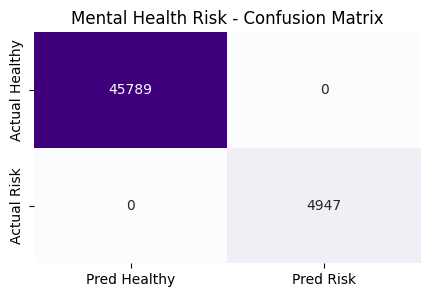


 TRAINING MODEL: PHYSICAL HEALTH RISK
Imbalance Ratio: 175405 Healthy vs 27539 At-Risk
Applying scale_pos_weight penalty: 6.37
Training XGBoost on 202944 records...

 Physical Health Risk ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     43909
           1       1.00      1.00      1.00      6827

    accuracy                           1.00     50736
   macro avg       1.00      1.00      1.00     50736
weighted avg       1.00      1.00      1.00     50736



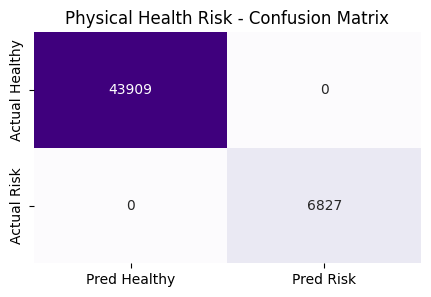

In [22]:
def train_and_evaluate_imbalanced(X_train, y_train, X_test, y_test, target_name):
    print(f"\n{'='*50}")
    print(f" TRAINING MODEL: {target_name.upper()}")
    print(f"{'='*50}")
    
    # 1. Calculate the dynamic penalty weight (Majority Count / Minority Count)
    # This forces the model to care about the 10% minority class
    class_counts = y_train.value_counts()
    weight = class_counts[0] / class_counts[1]
    print(f"Imbalance Ratio: {class_counts[0]} Healthy vs {class_counts[1]} At-Risk")
    print(f"Applying scale_pos_weight penalty: {weight:.2f}")
    
    # 2. Initialize Cost-Sensitive XGBoost
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,           # Kept shallow to prevent overfitting on the minority class
        learning_rate=0.05,
        scale_pos_weight=weight, # THE MAGIC PARAMETER
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    )
    
    # 3. Train
    print(f"Training XGBoost on {len(X_train)} records...")
    model.fit(X_train, y_train)
    
    # 4. Evaluate
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\n {target_name} ROC-AUC Score: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # 5. Visual Confusion Matrix
    plt.figure(figsize=(5, 3))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=['Pred Healthy', 'Pred Risk'],
                yticklabels=['Actual Healthy', 'Actual Risk'])
    plt.title(f'{target_name} - Confusion Matrix')
    plt.show()
    
    return model

# Train Mental Health Model
# (Assuming your splits are named X_train, X_test, y_train_mental, y_test_mental)
mental_model = train_and_evaluate_imbalanced(
    X_train, y_train_mental, X_test, y_test_mental, "Mental Health Risk"
)

# Train Physical Health Model
# (Assuming your splits are named X_train, X_test, y_train_physical, y_test_physical)
physical_model = train_and_evaluate_imbalanced(
    X_train, y_train_physical, X_test, y_test_physical, "Physical Health Risk"
)

### ⚠️ Finding the Data Leak

--- 🕵️ FORENSIC DIAGNOSTIC: CDC DATA LEAK ---


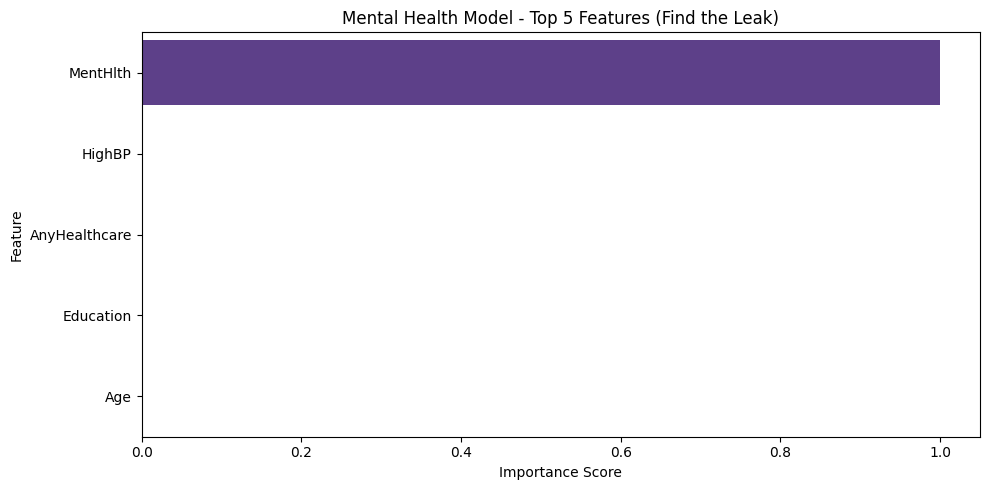

Top 5 Features driving the Mental Health 100% accuracy:


,Feature,Importance
14,MentHlth,1.0
0,HighBP,0.0
11,AnyHealthcare,0.0
19,Education,0.0
18,Age,0.0


In [ ]:

# Extract importances directly from the trained Mental Health XGBoost model
importances_mental = mental_model.feature_importances_
feature_names_cdc = X_train.columns

# Create and sort DataFrame
df_imp_mental = pd.DataFrame({
    'Feature': feature_names_cdc,
    'Importance': importances_mental
}).sort_values(by='Importance', ascending=False)

# Visualize the Top 5
plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp_mental.head(5), x='Importance', y='Feature', palette='Purples_r')
plt.title("Mental Health Model - Top 5 Features (Find the Leak)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 5 Features driving the Mental Health 100% accuracy:")
display(df_imp_mental.head(5))


### Removing the Data Leak and Re-Training the Models

Dropped columns: ['MentHlth', 'PhysHlth']
Remaining features for prediction: 19

Retraining Mental Health Model without 'MentHlth' leak...

 TRAINING MODEL: MENTAL HEALTH RISK (CLEAN)
Imbalance Ratio: 182874 Healthy vs 20070 At-Risk
Applying scale_pos_weight penalty: 9.11
Training XGBoost on 202944 records...

 Mental Health Risk (Clean) ROC-AUC Score: 0.8035

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     45789
           1       0.24      0.70      0.36      4947

    accuracy                           0.76     50736
   macro avg       0.60      0.73      0.60     50736
weighted avg       0.89      0.76      0.80     50736



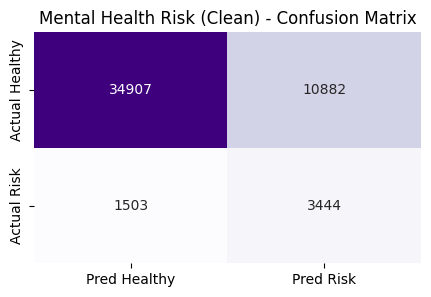

Retraining Physical Health Model without 'PhysHlth' leak...

 TRAINING MODEL: PHYSICAL HEALTH RISK (CLEAN)
Imbalance Ratio: 175405 Healthy vs 27539 At-Risk
Applying scale_pos_weight penalty: 6.37
Training XGBoost on 202944 records...

 Physical Health Risk (Clean) ROC-AUC Score: 0.8811

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.84      0.90     43909
           1       0.43      0.78      0.56      6827

    accuracy                           0.83     50736
   macro avg       0.70      0.81      0.73     50736
weighted avg       0.89      0.83      0.85     50736



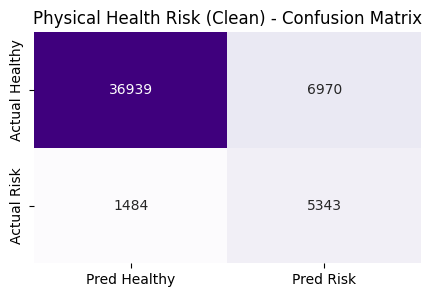

In [24]:
# 1. Identify the leaky columns
cdc_leaks = ['MentHlth', 'PhysHlth']

# 2. Safely drop them from both the Train and Test arrays
X_train_clean = X_train.drop(columns=[col for col in cdc_leaks if col in X_train.columns])
X_test_clean = X_test.drop(columns=[col for col in cdc_leaks if col in X_test.columns])

print(f"Dropped columns: {cdc_leaks}")
print(f"Remaining features for prediction: {len(X_train_clean.columns)}\n")

# 3. Retrain Mental Health Model on CLEAN data
print("Retraining Mental Health Model without 'MentHlth' leak...")
mental_model_clean = train_and_evaluate_imbalanced(
    X_train_clean, y_train_mental, X_test_clean, y_test_mental, "Mental Health Risk (Clean)"
)

# 4. Retrain Physical Health Model on CLEAN data
print("Retraining Physical Health Model without 'PhysHlth' leak...")
physical_model_clean = train_and_evaluate_imbalanced(
    X_train_clean, y_train_physical, X_test_clean, y_test_physical, "Physical Health Risk (Clean)"
)

## TRAINING DIABETES ENSEMBLE

Droping the two columns from above ('MentHlth'& 'PhysHlth') because they do not add much to the accuracy of this model. (only +0.0003) \
Droping it will be easier and more efficient to handle later in the backend.

Cleaned Diabetes training features.
Training the Diabetes Soft-Voting Ensemble on SMOTE-balanced data...

---  TRUE CLINICAL EVALUATION (DIABETES) ---
 REAL ROC-AUC Score: 0.8313

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     43739
         1.0       0.37      0.62      0.47      6997

    accuracy                           0.80     50736
   macro avg       0.65      0.73      0.67     50736
weighted avg       0.86      0.80      0.82     50736



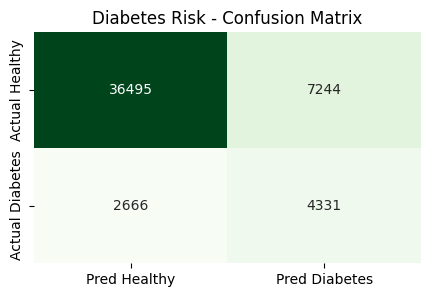

In [26]:
# 1. Droping the leaky columns from the Diabetes SMOTE arrays
cdc_leaks = ['MentHlth', 'PhysHlth']
X_train_diab_clean = X_train_diabetes_balanced.drop(columns=[col for col in cdc_leaks if col in X_train_diabetes_balanced.columns])
X_test_diab_clean = X_test.drop(columns=[col for col in cdc_leaks if col in X_test.columns])

print("Cleaned Diabetes training features.")

# 2. Initialize the Base Models for the Ensemble
log_reg_diab = LogisticRegression(random_state=42, max_iter=1000)
rf_model_diab = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
xgb_model_diab = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05, 
    random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1
)

# 3. Build and Train the Soft-Voting Ensemble
diabetes_ensemble = VotingClassifier(
    estimators=[('lr', log_reg_diab), ('rf', rf_model_diab), ('xgb', xgb_model_diab)],
    voting='soft'
)

print("Training the Diabetes Soft-Voting Ensemble on SMOTE-balanced data...")
diabetes_ensemble.fit(X_train_diab_clean, y_train_diabetes_balanced)

# 4. True Clinical Evaluation (On Pristine Test Set)
print("\n---  TRUE CLINICAL EVALUATION (DIABETES) ---")
y_pred_proba_diab = diabetes_ensemble.predict_proba(X_test_diab_clean)[:, 1]
y_pred_diab = diabetes_ensemble.predict(X_test_diab_clean)

roc_auc_diab = roc_auc_score(y_test_diabetes, y_pred_proba_diab)
print(f" REAL ROC-AUC Score: {roc_auc_diab:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_diabetes, y_pred_diab))

# 5. Visual Confusion Matrix
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_test_diabetes, y_pred_diab)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred Healthy', 'Pred Diabetes'],
            yticklabels=['Actual Healthy', 'Actual Diabetes'])
plt.title('Diabetes Risk - Confusion Matrix')
plt.show()

## Exporting the models

In [28]:
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(diabetes_ensemble, os.path.join(MODELS_DIR, 'diabetes_model.joblib'))
joblib.dump(mental_model_clean, os.path.join(MODELS_DIR, 'mental_health_model.joblib'))
joblib.dump(physical_model_clean, os.path.join(MODELS_DIR, 'physical_health_model.joblib'))

joblib.dump(scaler, os.path.join(MODELS_DIR, 'cdc_scaler.joblib')) # save the scaler for future use in the API

print(" CDC Models (Diabetes, Mental, Physical) successfully saved to the /models/ folder!")

 CDC Models (Diabetes, Mental, Physical) successfully saved to the /models/ folder!
